In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Carica i due file
match = pd.read_csv("2026_04_12_Full Match.csv", sep=';', decimal=',', encoding='utf-8-sig')
training = pd.read_csv("2026_04_07_Full Training.csv", sep=';', decimal=',', encoding='utf-8-sig')

# Prima occhiata
print("=== PARTITA ===")
print(match.shape)
print(match.head())

print("\n=== ALLENAMENTO ===")
print(training.shape)
print(training.head())

=== PARTITA ===
(7, 24)
         Player  DISTANZA  DISTANZA AL MINUTO  SPESA ENERGETICA  \
0  Team Average      9890                  87                53   
1      D'ORAZIO      8793                  77                47   
2      GIANOTTI      9593                  84                50   
3        JAMMEH      9582                  84                51   
4      MAMARANG     11497                 101                61   

   DISTANZA ALTA VELOCITA'  DISTANZA AD ALTA DECELERAZIONE  \
0                     1190                             349   
1                     1218                             317   
2                      900                             272   
3                      908                             329   
4                     1422                             349   

   DISTANZA AD ALTA POTENZA  POTENZA METABOLICA MEDIA  \
0                      2047                       7.7   
1                      1975                       6.9   
2                      1692  

In [16]:
# Rimuoviamo la riga "Team Average" da entrambi
match = match[match['Player'] != 'Team Average'].reset_index(drop=True)
training = training[training['Player'] != 'Team Average'].reset_index(drop=True)

# Controlliamo valori nulli
print("=== VALORI NULLI PARTITA ===")
print(match.isnull().sum())

print("\n=== VALORI NULLI ALLENAMENTO ===")
print(training.isnull().sum())

# Controlliamo i tipi di dati
print("\n=== TIPI DI DATI PARTITA ===")
print(match.dtypes)

=== VALORI NULLI PARTITA ===
Player                            0
DISTANZA                          0
DISTANZA AL MINUTO                0
SPESA ENERGETICA                  0
DISTANZA ALTA VELOCITA'           0
DISTANZA AD ALTA DECELERAZIONE    0
DISTANZA AD ALTA POTENZA          0
POTENZA METABOLICA MEDIA          0
DISTANZA EQUIVALENTE AL MINUTO    0
SPESA ANAEROBICA                  0
DISTANZA >25 KM/H                 0
SMax (kmh)                        0
D<6 km/h                          0
N ACC > 3 m/s2                    0
N ACC > 2 m/s2                    0
N DEC < -3 m/s2                   0
N DEC < -2 m/s2                   0
Strength index                    0
HrAvg                             0
HRmax                             0
D_HRHI                            0
D_AccHI Pl                        0
SMax (kmh).1                      0
Unnamed: 23                       6
dtype: int64

=== VALORI NULLI ALLENAMENTO ===
Player                            0
DISTANZA                

In [4]:
# Eliminiamo le colonne inutili
match = match.drop(columns=['SMax (kmh).1', 'Unnamed: 23'])
training = training.drop(columns=['SMax (kmh).1', 'Unnamed: 23'])

# Verifica finale
print("=== PARTITA - colonne rimaste ===")
print(match.columns.tolist())
print(f"\nGiocatori partita: {match['Player'].tolist()}")
print(f"Giocatori allenamento: {training['Player'].tolist()}")

print(f"\nDimensioni partita: {match.shape}")
print(f"Dimensioni allenamento: {training.shape}")

=== PARTITA - colonne rimaste ===
['Player', 'DISTANZA', 'DISTANZA AL MINUTO', 'SPESA ENERGETICA', "DISTANZA ALTA VELOCITA'", 'DISTANZA AD ALTA DECELERAZIONE', 'DISTANZA AD ALTA POTENZA', 'POTENZA METABOLICA MEDIA', 'DISTANZA EQUIVALENTE AL MINUTO', 'SPESA ANAEROBICA', 'DISTANZA >25 KM/H', 'SMax (kmh)', 'D<6 km/h', 'N ACC > 3 m/s2', 'N ACC > 2 m/s2', 'N DEC < -3 m/s2', 'N DEC < -2 m/s2', 'Strength index', 'HrAvg', 'HRmax', 'D_HRHI', 'D_AccHI Pl']

Giocatori partita: ["D'ORAZIO", 'GIANOTTI', 'JAMMEH', 'MAMARANG', 'PAOLONI', 'SAVELLONI']
Giocatori allenamento: ['ANCILLAI', "D'ABBONDANZA", 'JAMMEH', 'MAMARANG', 'MANGA', 'PAOLONI']

Dimensioni partita: (6, 22)
Dimensioni allenamento: (6, 22)


In [5]:
# Statistiche base per la partita
print("=== STATISTICHE PARTITA ===")
print(match.describe().round(1))

print("\n=== STATISTICHE ALLENAMENTO ===")
print(training.describe().round(1))

=== STATISTICHE PARTITA ===
       DISTANZA  DISTANZA AL MINUTO  SPESA ENERGETICA  \
count       6.0                 6.0               6.0   
mean     9890.3                86.7              52.8   
std      1038.9                 9.1               5.4   
min      8793.0                77.0              47.0   
25%      9216.8                81.0              50.0   
50%      9587.5                84.0              50.5   
75%     10484.8                91.5              56.2   
max     11497.0               101.0              61.0   

       DISTANZA ALTA VELOCITA'  DISTANZA AD ALTA DECELERAZIONE  \
count                      6.0                             6.0   
mean                    1189.8                           348.5   
std                      234.0                            55.9   
min                      900.0                           272.0   
25%                      985.5                           320.0   
50%                     1252.0                           339.0

In [6]:
# Ogni giocatore vs media squadra - PARTITA
media = match['DISTANZA'].mean()

for _, row in match.iterrows():
    diff = row['DISTANZA'] - media
    segno = '🔺' if diff > 0 else '🔻'
    print(f"{row['Player']:<15} {row['DISTANZA']} m   {segno} {abs(diff):.0f}m dalla media")

D'ORAZIO        8793 m   🔻 1097m dalla media
GIANOTTI        9593 m   🔻 297m dalla media
JAMMEH          9582 m   🔻 308m dalla media
MAMARANG        11497 m   🔺 1607m dalla media
PAOLONI         10782 m   🔺 892m dalla media
SAVELLONI       9095 m   🔻 795m dalla media


In [7]:
# Ogni giocatore vs media squadra - ALLENAMENTO
media = training['DISTANZA'].mean()

for _, row in training.iterrows():
    diff = row['DISTANZA'] - media
    segno = '🔺' if diff > 0 else '🔻'
    print(f"{row['Player']:<15} {row['DISTANZA']} m   {segno} {abs(diff):.0f}m dalla media")

ANCILLAI        7370 m   🔺 632m dalla media
D'ABBONDANZA    6527 m   🔻 211m dalla media
JAMMEH          6178 m   🔻 560m dalla media
MAMARANG        7417 m   🔺 679m dalla media
MANGA           5973 m   🔻 765m dalla media
PAOLONI         6962 m   🔺 224m dalla media


In [8]:
# Confronto accelerazioni - PARTITA
print("=== ACCELERAZIONI INTENSE - PARTITA ===")
media_match = match['N ACC > 3 m/s2'].mean()

for _, row in match.iterrows():
    diff = row['N ACC > 3 m/s2'] - media_match
    segno = '🔺' if diff > 0 else '🔻'
    print(f"{row['Player']:<15} {row['N ACC > 3 m/s2']} acc   {segno} {abs(diff):.1f} dalla media")

# Confronto accelerazioni - ALLENAMENTO
print("\n=== ACCELERAZIONI INTENSE - ALLENAMENTO ===")
media_training = training['N ACC > 3 m/s2'].mean()

for _, row in training.iterrows():
    diff = row['N ACC > 3 m/s2'] - media_training
    segno = '🔺' if diff > 0 else '🔻'
    print(f"{row['Player']:<15} {row['N ACC > 3 m/s2']} acc   {segno} {abs(diff):.1f} dalla media")

=== ACCELERAZIONI INTENSE - PARTITA ===
D'ORAZIO        17 acc   🔻 10.0 dalla media
GIANOTTI        24 acc   🔻 3.0 dalla media
JAMMEH          34 acc   🔺 7.0 dalla media
MAMARANG        37 acc   🔺 10.0 dalla media
PAOLONI         28 acc   🔺 1.0 dalla media
SAVELLONI       22 acc   🔻 5.0 dalla media

=== ACCELERAZIONI INTENSE - ALLENAMENTO ===
ANCILLAI        33 acc   🔻 3.8 dalla media
D'ABBONDANZA    38 acc   🔺 1.2 dalla media
JAMMEH          28 acc   🔻 8.8 dalla media
MAMARANG        34 acc   🔻 2.8 dalla media
MANGA           41 acc   🔺 4.2 dalla media
PAOLONI         47 acc   🔺 10.2 dalla media


In [9]:
# Giocatori in comune
in_comune = ['JAMMEH', 'MAMARANG', 'PAOLONI']

# Filtriamo solo loro
match_comuni = match[match['Player'].isin(in_comune)].set_index('Player')
training_comuni = training[training['Player'].isin(in_comune)].set_index('Player')

# Confronto distanza e accelerazioni
metriche = ['DISTANZA', 'N ACC > 3 m/s2', 'SMax (kmh)', 'HrAvg']

for metrica in metriche:
    print(f"\n=== {metrica} ===")
    for giocatore in in_comune:
        val_match = match_comuni.loc[giocatore, metrica]
        val_training = training_comuni.loc[giocatore, metrica]
        diff = val_match - val_training
        segno = '🔺' if diff > 0 else '🔻'
        print(f"{giocatore:<15} Partita: {val_match}   Allenamento: {val_training}   {segno} {abs(diff):.1f}")


=== DISTANZA ===
JAMMEH          Partita: 9582   Allenamento: 6178   🔺 3404.0
MAMARANG        Partita: 11497   Allenamento: 7417   🔺 4080.0
PAOLONI         Partita: 10782   Allenamento: 6962   🔺 3820.0

=== N ACC > 3 m/s2 ===
JAMMEH          Partita: 34   Allenamento: 28   🔺 6.0
MAMARANG        Partita: 37   Allenamento: 34   🔺 3.0
PAOLONI         Partita: 28   Allenamento: 47   🔻 19.0

=== SMax (kmh) ===
JAMMEH          Partita: 30.1   Allenamento: 21.6   🔺 8.5
MAMARANG        Partita: 28.4   Allenamento: 24.8   🔺 3.6
PAOLONI         Partita: 29.4   Allenamento: 24.0   🔺 5.4

=== HrAvg ===
JAMMEH          Partita: 136   Allenamento: 152   🔻 16.0
MAMARANG        Partita: 127   Allenamento: 146   🔻 19.0
PAOLONI         Partita: 99   Allenamento: 139   🔻 40.0


In [10]:
# Analisi carico fisico - PARTITA
metriche_carico = ['SPESA ENERGETICA', 'DISTANZA AD ALTA POTENZA', 'POTENZA METABOLICA MEDIA']

print("=== CARICO FISICO - PARTITA ===")
for metrica in metriche_carico:
    media = match[metrica].mean()
    print(f"\n{metrica} (media: {media:.1f})")
    for _, row in match.iterrows():
        diff = row[metrica] - media
        segno = '🔺' if diff > 0 else '🔻'
        print(f"  {row['Player']:<15} {row[metrica]}   {segno} {abs(diff):.1f} dalla media")

=== CARICO FISICO - PARTITA ===

SPESA ENERGETICA (media: 52.8)
  D'ORAZIO        47   🔻 5.8 dalla media
  GIANOTTI        50   🔻 2.8 dalla media
  JAMMEH          51   🔻 1.8 dalla media
  MAMARANG        61   🔺 8.2 dalla media
  PAOLONI         58   🔺 5.2 dalla media
  SAVELLONI       50   🔻 2.8 dalla media

DISTANZA AD ALTA POTENZA (media: 2047.3)
  D'ORAZIO        1975   🔻 72.3 dalla media
  GIANOTTI        1692   🔻 355.3 dalla media
  JAMMEH          1750   🔻 297.3 dalla media
  MAMARANG        2551   🔺 503.7 dalla media
  PAOLONI         2270   🔺 222.7 dalla media
  SAVELLONI       2046   🔻 1.3 dalla media

POTENZA METABOLICA MEDIA (media: 7.7)
  D'ORAZIO        6.9   🔻 0.8 dalla media
  GIANOTTI        7.4   🔻 0.3 dalla media
  JAMMEH          7.5   🔻 0.2 dalla media
  MAMARANG        8.9   🔺 1.2 dalla media
  PAOLONI         8.5   🔺 0.8 dalla media
  SAVELLONI       7.2   🔻 0.5 dalla media


In [11]:
# Analisi carico fisico - ALLENAMENTO
print("=== CARICO FISICO - ALLENAMENTO ===")
for metrica in metriche_carico:
    media = training[metrica].mean()
    print(f"\n{metrica} (media: {media:.1f})")
    for _, row in training.iterrows():
        diff = row[metrica] - media
        segno = '🔺' if diff > 0 else '🔻'
        print(f"  {row['Player']:<15} {row[metrica]}   {segno} {abs(diff):.1f} dalla media")

=== CARICO FISICO - ALLENAMENTO ===

SPESA ENERGETICA (media: 36.8)
  ANCILLAI        40   🔺 3.2 dalla media
  D'ABBONDANZA    37   🔺 0.2 dalla media
  JAMMEH          33   🔻 3.8 dalla media
  MAMARANG        40   🔺 3.2 dalla media
  MANGA           33   🔻 3.8 dalla media
  PAOLONI         38   🔺 1.2 dalla media

DISTANZA AD ALTA POTENZA (media: 1188.0)
  ANCILLAI        1345   🔺 157.0 dalla media
  D'ABBONDANZA    1251   🔺 63.0 dalla media
  JAMMEH          916   🔻 272.0 dalla media
  MAMARANG        1209   🔺 21.0 dalla media
  MANGA           1087   🔻 101.0 dalla media
  PAOLONI         1320   🔺 132.0 dalla media

POTENZA METABOLICA MEDIA (media: 6.5)
  ANCILLAI        7.1   🔺 0.5 dalla media
  D'ABBONDANZA    6.6   🔺 0.0 dalla media
  JAMMEH          5.8   🔻 0.8 dalla media
  MAMARANG        7.1   🔺 0.5 dalla media
  MANGA           5.9   🔻 0.6 dalla media
  PAOLONI         6.8   🔺 0.2 dalla media


In [12]:
# Analisi cardiaca - PARTITA e ALLENAMENTO
metriche_cardio = ['HrAvg', 'HRmax', 'D_HRHI']

for dataset, nome in [(match, 'PARTITA'), (training, 'ALLENAMENTO')]:
    print(f"\n=== ANALISI CARDIACA - {nome} ===")
    for metrica in metriche_cardio:
        media = dataset[metrica].mean()
        print(f"\n{metrica} (media: {media:.1f})")
        for _, row in dataset.iterrows():
            diff = row[metrica] - media
            segno = '🔺' if diff > 0 else '🔻'
            print(f"  {row['Player']:<15} {row[metrica]}   {segno} {abs(diff):.1f} dalla media")


=== ANALISI CARDIACA - PARTITA ===

HrAvg (media: 139.8)
  D'ORAZIO        154   🔺 14.2 dalla media
  GIANOTTI        158   🔺 18.2 dalla media
  JAMMEH          136   🔻 3.8 dalla media
  MAMARANG        127   🔻 12.8 dalla media
  PAOLONI         99   🔻 40.8 dalla media
  SAVELLONI       165   🔺 25.2 dalla media

HRmax (media: 201.5)
  D'ORAZIO        227   🔺 25.5 dalla media
  GIANOTTI        194   🔻 7.5 dalla media
  JAMMEH          203   🔺 1.5 dalla media
  MAMARANG        208   🔺 6.5 dalla media
  PAOLONI         183   🔻 18.5 dalla media
  SAVELLONI       194   🔻 7.5 dalla media

D_HRHI (media: 3941.7)
  D'ORAZIO        6157   🔺 2215.3 dalla media
  GIANOTTI        6123   🔺 2181.3 dalla media
  JAMMEH          1792   🔻 2149.7 dalla media
  MAMARANG        1379   🔻 2562.7 dalla media
  PAOLONI         129   🔻 3812.7 dalla media
  SAVELLONI       8070   🔺 4128.3 dalla media

=== ANALISI CARDIACA - ALLENAMENTO ===

HrAvg (media: 139.7)
  ANCILLAI        138   🔻 1.7 dalla media
  D'ABB

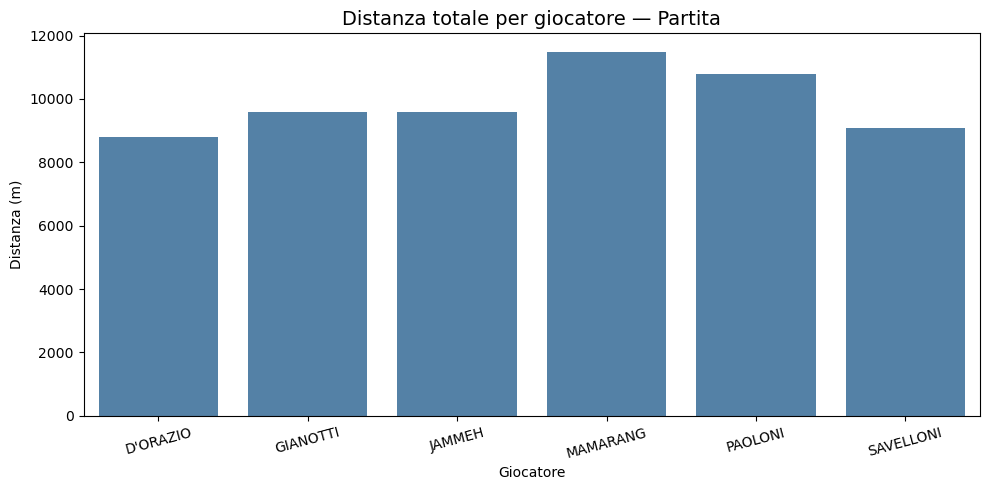

In [18]:
# Grafico 1 - Distanza per giocatore in partita
plt.figure(figsize=(10, 5))
sns.barplot(data=match, x='Player', y='DISTANZA', color='steelblue')
plt.title('Distanza totale per giocatore — Partita', fontsize=14)
plt.xlabel('Giocatore')
plt.ylabel('Distanza (m)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

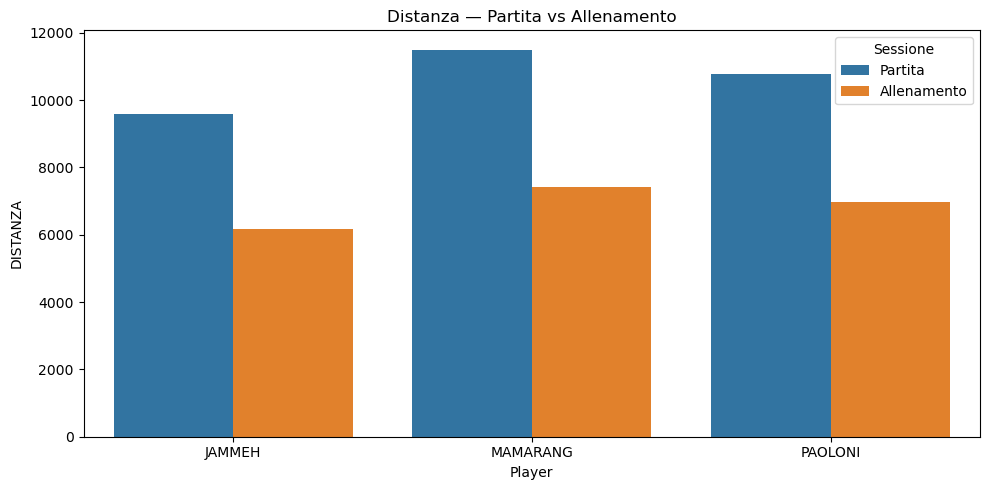

In [19]:
# Grafico 2 - Partita vs Allenamento per i 3 in comune
in_comune = ['JAMMEH', 'MAMARANG', 'PAOLONI']
match_comuni = match[match['Player'].isin(in_comune)].copy()
training_comuni = training[training['Player'].isin(in_comune)].copy()
match_comuni['Sessione'] = 'Partita'
training_comuni['Sessione'] = 'Allenamento'
confronto = pd.concat([match_comuni, training_comuni])

plt.figure(figsize=(10, 5))
sns.barplot(data=confronto, x='Player', y='DISTANZA', hue='Sessione')
plt.title('Distanza — Partita vs Allenamento')
plt.tight_layout()
plt.show()



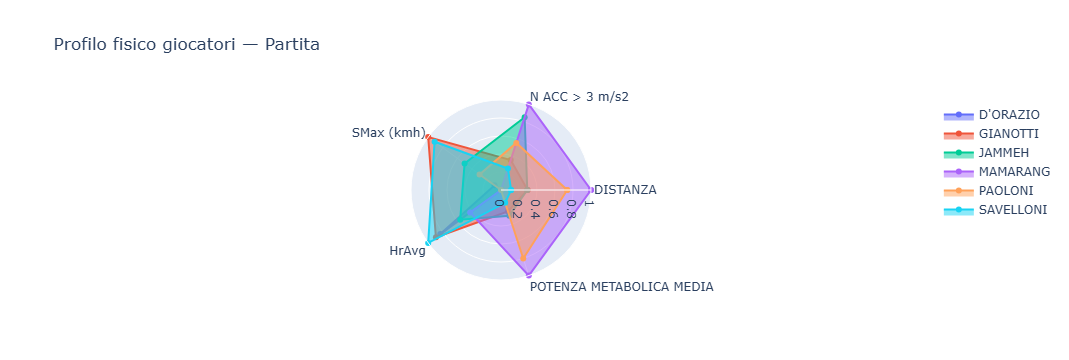

In [20]:
import plotly.graph_objects as go

# Metriche per il radar
metriche_radar = ['DISTANZA', 'N ACC > 3 m/s2', 'SMax (kmh)', 'HrAvg', 'POTENZA METABOLICA MEDIA']

# Normalizziamo da 0 a 1
match_norm = match.copy()
for col in metriche_radar:
    match_norm[col] = (match[col] - match[col].min()) / (match[col].max() - match[col].min())

# Creiamo il radar per ogni giocatore
fig = go.Figure()

for _, row in match_norm.iterrows():
    valori = [row[m] for m in metriche_radar]
    valori += valori[:1]  # chiude il poligono
    
    fig.add_trace(go.Scatterpolar(
        r=valori,
        theta=metriche_radar + [metriche_radar[0]],
        fill='toself',
        name=row['Player']
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='Profilo fisico giocatori — Partita',
    showlegend=True
)

fig.show()